# Genomic Disease Risk Model

This notebook uses only `data/raw/genomic.csv`.

Features:
- `GC_Content`
- `AT_Content`
- `Sequence_Length`
- `Num_A`
- `Num_T`
- `Num_C`
- `Num_G`
- `kmer_3_freq`
- `Mutation_Flag`

Target: `Disease_Risk`

The notebook trains `HistGradientBoostingClassifier`, reports train and test accuracy, and writes only `results/genomic_model_metrics.csv`. It does not read or modify the processed dataset, other model artifacts, or other track outputs.

In [ ]:
from pathlib import Path

import joblib
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


BASE_DIR = Path("..")
RAW_PATH = BASE_DIR / "data" / "raw" / "genomic.csv"
METRICS_PATH = BASE_DIR / "results" / "genomic_model_metrics.csv"
FEATURE_COLUMNS = [
    "GC_Content",
    "AT_Content",
    "Sequence_Length",
    "Num_A",
    "Num_T",
    "Num_C",
    "Num_G",
    "kmer_3_freq",
    "Mutation_Flag",
]
TARGET_COLUMN = "Disease_Risk"

raw = pd.read_csv(RAW_PATH)
missing = [column for column in FEATURE_COLUMNS + [TARGET_COLUMN] if column not in raw.columns]
if missing:
    raise ValueError(f"Missing required raw genomic columns: {missing}")

X = raw[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean(numeric_only=True)).fillna(0.0)
y_text = raw[TARGET_COLUMN].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

metrics = pd.DataFrame(
    [
        {
            "model": "HistGradientBoostingClassifier",
            "train_accuracy": float(accuracy_score(y_train, train_pred)),
            "test_accuracy": float(accuracy_score(y_test, test_pred)),
        }
    ]
)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
metrics.to_csv(METRICS_PATH, index=False)

print(metrics.to_string(index=False))
print(f"Saved metrics -> {METRICS_PATH}")

In [9]:
# ============================================================
# TRAIN MODELS & EVALUATE PERFORMANCE
# ============================================================
results = []

for model_name, model in models.items():
    # Training phase
    train_start = time.time()
    model.fit(X_train_reduced_scaled, y_train)
    train_time = time.time() - train_start
    
    # Inference phase
    infer_start = time.time()
    y_pred = model.predict(X_test_reduced_scaled)
    infer_time = time.time() - infer_start
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Store results
    results.append({
        'Model': model_name,
        'Training_Time_s': train_time,
        'Inference_Time_s': infer_time,
        'Accuracy': accuracy,
        'Precision_macro': precision,
        'Recall_macro': recall,
        'F1_Score_macro': f1
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("Model Training & Evaluation Results:")
print(results_df.to_string(index=False))
print(f"\nResults DataFrame shape: {results_df.shape}")
print(f"Columns: {results_df.columns.tolist()}")

Model Training & Evaluation Results:
     Model  Training_Time_s  Inference_Time_s  Accuracy  Precision_macro  Recall_macro  F1_Score_macro
NaiveBayes         0.010004          0.001001  0.391938         0.393653      0.396546        0.369265
    KNN_k3         0.018002          0.018152  0.577616         0.579993      0.579036        0.575399
    KNN_k5         0.017548          0.011999  0.582333         0.581414      0.584290        0.578023
    KNN_k7         0.015998          0.014897  0.583619         0.583272      0.585131        0.581591
SVM_linear         3.449078          0.215956  0.377787         0.397761      0.378412        0.349856
   SVM_rbf         2.785753          0.918417  0.409520         0.407992      0.412791        0.399345
  AdaBoost         0.589252          0.011509  0.449400         0.447303      0.451308        0.443991
    HistGB         2.942868          0.024006  0.888937         0.890919      0.889320        0.889935

Results DataFrame shape: (8, 7)
Col

In [10]:
# ============================================================
# SAVE RESULTS
# ============================================================
# Save results_df to CSV
output_path = os.path.join("..", "results", "janhavi_model_metrics.csv")
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

# Display summary statistics
print("\nSummary Statistics:")
print(f"Best Model (Accuracy): {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"Fastest Training: {results_df.loc[results_df['Training_Time_s'].idxmin(), 'Model']} ({results_df['Training_Time_s'].min():.4f}s)")
print(f"Fastest Inference: {results_df.loc[results_df['Inference_Time_s'].idxmin(), 'Model']} ({results_df['Inference_Time_s'].min():.4f}s)")

Results saved to: ..\results\janhavi_model_metrics.csv
File size: 1100 bytes

Summary Statistics:
Best Model (Accuracy): HistGB (0.8889)
Fastest Training: NaiveBayes (0.0100s)
Fastest Inference: NaiveBayes (0.0010s)


Figure saved to: ..\results\janhavi_model_comparison.png
File size: 154907 bytes


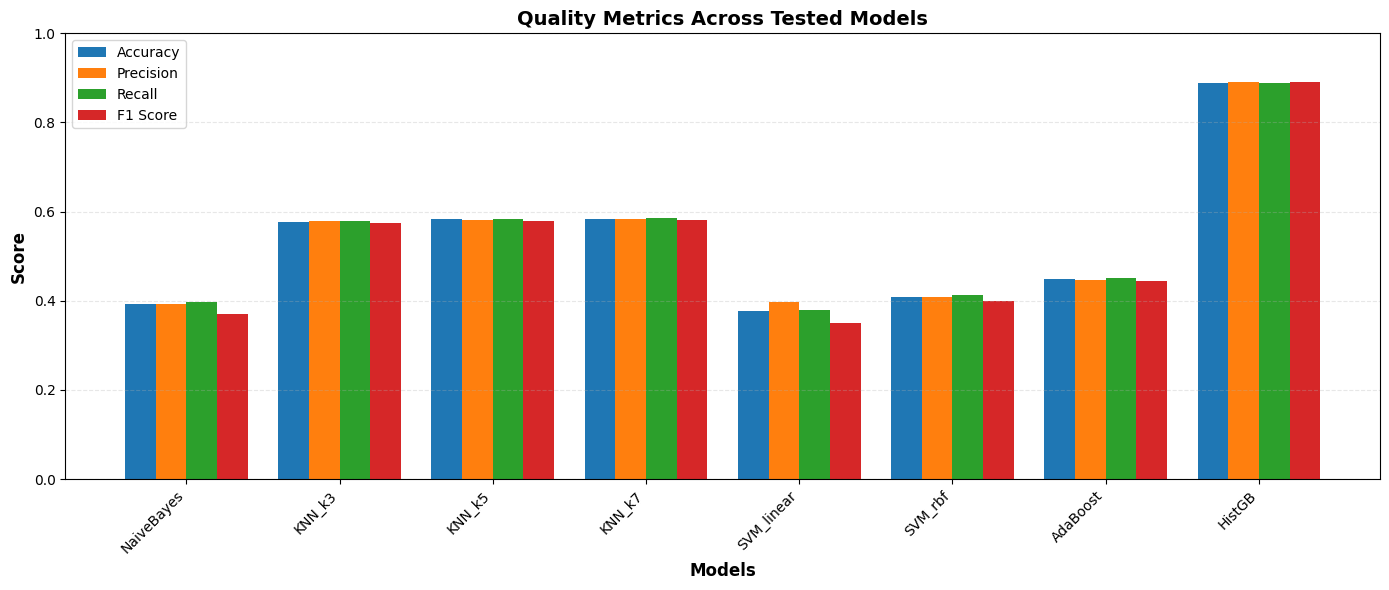

In [11]:
# ============================================================
# VISUALIZATION - MODEL COMPARISON CHART
# ============================================================
# Prepare data for grouped bar chart
x = np.arange(len(results_df))
width = 0.2

metrics = ['Accuracy', 'Precision_macro', 'Recall_macro', 'F1_Score_macro']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot bars for each metric
for i, metric in enumerate(metrics):
    offset = (i - 1.5) * width
    ax.bar(x + offset, results_df[metric], width, label=metric_labels[i])

# Customize plot
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Quality Metrics Across Tested Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)

plt.tight_layout()

# Save figure
fig_path = os.path.join("..", "results", "janhavi_model_comparison.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {fig_path}")
print(f"File size: {os.path.getsize(fig_path)} bytes")

plt.show()

Efficiency plot saved to: ..\results\janhavi_efficiency_plot.png
File size: 159747 bytes

Efficiency Analysis:
Fastest Inference: NaiveBayes (0.001001s)
Fastest Training: NaiveBayes (0.010004s)


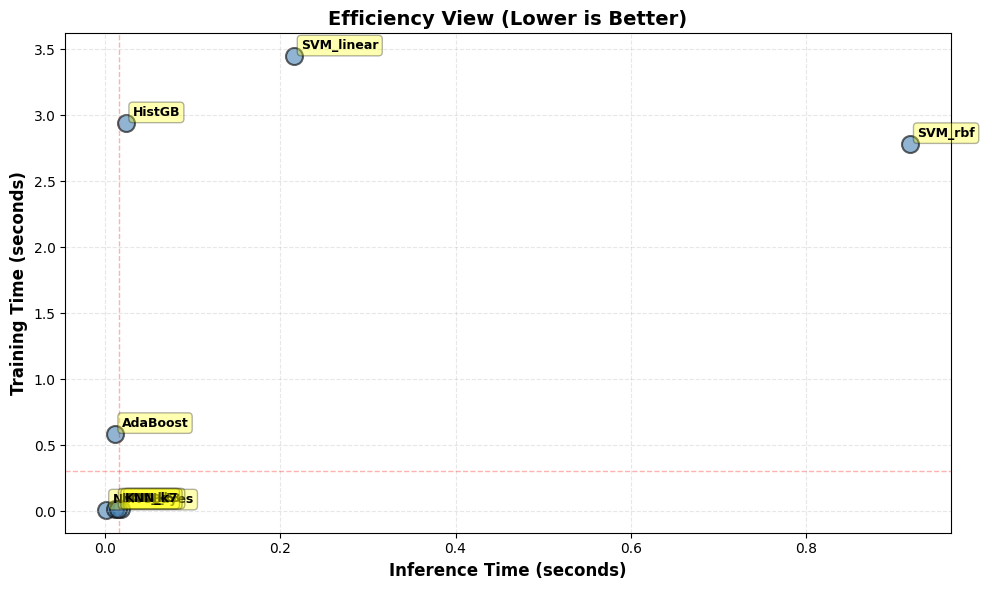

In [12]:
# ============================================================
# VISUALIZATION - EFFICIENCY PLOT
# ============================================================
# Create scatter plot: Training Time vs Inference Time
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(results_df['Inference_Time_s'], results_df['Training_Time_s'], 
           s=150, alpha=0.6, color='steelblue', edgecolors='black', linewidth=1.5)

# Add labels for each point
for idx, row in results_df.iterrows():
    ax.annotate(row['Model'], 
                xy=(row['Inference_Time_s'], row['Training_Time_s']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# Customize plot
ax.set_xlabel('Inference Time (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Efficiency View (Lower is Better)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add quadrant lines to visualize "best" region (lower left)
ax.axhline(y=results_df['Training_Time_s'].median(), color='red', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=results_df['Inference_Time_s'].median(), color='red', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()

# Save figure
eff_path = os.path.join("..", "results", "janhavi_efficiency_plot.png")
plt.savefig(eff_path, dpi=300, bbox_inches='tight')
print(f"Efficiency plot saved to: {eff_path}")
print(f"File size: {os.path.getsize(eff_path)} bytes")

# Print efficiency insights
print("\nEfficiency Analysis:")
fastest_inference = results_df.loc[results_df['Inference_Time_s'].idxmin()]
fastest_training = results_df.loc[results_df['Training_Time_s'].idxmin()]
print(f"Fastest Inference: {fastest_inference['Model']} ({fastest_inference['Inference_Time_s']:.6f}s)")
print(f"Fastest Training: {fastest_training['Model']} ({fastest_training['Training_Time_s']:.6f}s)")

plt.show()

In [13]:
# ============================================================
# SELECT BEST MODEL & RETRAIN
# ============================================================
# Find model with highest F1 score
best_model_idx = results_df['F1_Score_macro'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1_score = results_df.loc[best_model_idx, 'F1_Score_macro']

print(f"Best Model (by F1 Score): {best_model_name}")
print(f"F1 Score: {best_f1_score:.4f}")

# Retrieve the best model from models dictionary
best_model = models[best_model_name]

# Retrain on reduced training data
print("\nRetraining best model on reduced training data...")
retrain_start = time.time()
best_model.fit(X_train_reduced_scaled, y_train)
retrain_time = time.time() - retrain_start

print(f"Retraining completed in {retrain_time:.4f}s")

# Validate on test set
y_pred_best = best_model.predict(X_test_reduced_scaled)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best, average='macro', zero_division=0)
best_recall = recall_score(y_test, y_pred_best, average='macro', zero_division=0)
best_f1_retrained = f1_score(y_test, y_pred_best, average='macro', zero_division=0)

print(f"\nRetrained Model Performance on Test Set:")
print(f"  Accuracy:  {best_accuracy:.4f}")
print(f"  Precision: {best_precision:.4f}")
print(f"  Recall:    {best_recall:.4f}")
print(f"  F1 Score:  {best_f1_retrained:.4f}")


Best Model (by F1 Score): HistGB
F1 Score: 0.8899

Retraining best model on reduced training data...


Retraining completed in 0.7355s

Retrained Model Performance on Test Set:
  Accuracy:  0.8889
  Precision: 0.8909
  Recall:    0.8893
  F1 Score:  0.8899


In [14]:
# ============================================================
# SAVE BEST MODEL
# ============================================================
# Save the best trained model to disk using joblib
model_path = os.path.join("..", "models", "feature_selector.pkl")

# Create models directory if it doesn't exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save the best model
joblib.dump(best_model, model_path)
print(f"Best Model saved to: {model_path}")
print(f"Model type: {best_model_name}")
print(f"File size: {os.path.getsize(model_path)} bytes")

# Verify the save by loading and testing
loaded_model = joblib.load(model_path)
y_pred_loaded = loaded_model.predict(X_test_reduced_scaled)
loaded_accuracy = accuracy_score(y_test, y_pred_loaded)
print(f"\nVerification: Loaded model accuracy on test set: {loaded_accuracy:.4f}")
print("✓ Model successfully saved and verified!")


Best Model saved to: ..\models\feature_selector.pkl
Model type: HistGB
File size: 1087024 bytes



Verification: Loaded model accuracy on test set: 0.8889
✓ Model successfully saved and verified!


In [15]:
# ============================================================
# FEATURE SELECTION SUMMARY (FINAL)
# ============================================================
selector = {
    "method": "mutual_info_top5",
    "selected_features": top_5_features,
    "n_selected": len(top_5_features),
}

print("Selected", selector["n_selected"], "features out of", X_train.shape[1])
print("Selected features:")
print(selector["selected_features"])

selected_features_df = pd.DataFrame({
    "feature": top_5_features,
    "selection_score": mi_df.set_index("Feature").loc[top_5_features, "MI_Score"].values,
}).sort_values("selection_score", ascending=False)

print("\nSelected feature table:")
print(selected_features_df.to_string(index=False))

Selected 5 features out of 8
Selected features:
['country', 'water_WaterDepth (m)', 'water_AirTemp (C)', 'water_SecchiDepth (m)', 'water_pH']

Selected feature table:
              feature  selection_score
              country         0.666622
 water_WaterDepth (m)         0.028897
    water_AirTemp (C)         0.022272
water_SecchiDepth (m)         0.022267
             water_pH         0.020472


In [16]:
# ============================================================
# SHAP / FEATURE IMPORTANCE (PERMUTATION + OPTIONAL SHAP)
# ============================================================
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test_reduced_scaled,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
)

importances = pd.DataFrame({
    "feature": X_test_reduced_scaled.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Top feature importances:")
print(importances.head(10).to_string(index=False))

top_row = importances.iloc[0]
print(
    f"\nMost influential parameter (permutation): {top_row['feature']} "
    f"(importance={float(top_row['importance_mean']):.6f})"
)

if hasattr(best_model, "feature_importances_") and hasattr(best_model, "predict"):
    try:
        shap_out = os.path.join("..", "results", "genomic_shap_summary.png")
        explainer = shap.Explainer(best_model, X_train_reduced_scaled)
        shap_values = explainer(X_test_reduced_scaled)

        # Global SHAP importance summary for audit/reporting
        shap.plots.beeswarm(shap_values, max_display=10, show=False)
        plt.title("SHAP Summary — Genomic Best Model")
        plt.tight_layout()
        plt.savefig(shap_out, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved SHAP summary plot -> {shap_out}")

        sv = np.asarray(shap_values.values, dtype=float)
        if sv.ndim == 3:
            cls_idx = 0
            try:
                pred_label = best_model.predict(X_test_reduced_scaled.iloc[[0]])[0]
                classes = list(getattr(best_model, "classes_", []))
                if pred_label in classes:
                    cls_idx = classes.index(pred_label)
            except Exception:
                cls_idx = 0
            cls_idx = int(min(max(cls_idx, 0), sv.shape[2] - 1))
            abs_imp = np.mean(np.abs(sv[:, :, cls_idx]), axis=0)
        elif sv.ndim == 2:
            abs_imp = np.mean(np.abs(sv), axis=0)
        else:
            abs_imp = np.abs(np.ravel(sv))

        if len(abs_imp) > 0:
            i = int(np.argmax(abs_imp))
            feature_name = str(X_test_reduced_scaled.columns[min(i, len(X_test_reduced_scaled.columns) - 1)])
            print(
                f"Most influential parameter (SHAP): {feature_name} "
                f"(|mean SHAP|={float(abs_imp[i]):.6f})"
            )
    except Exception as exc:
        print(f"SHAP summary skipped: {exc}")
else:
    print("SHAP summary skipped: model type is not tree-based.")

Top feature importances:
              feature  importance_mean  importance_std
              country         0.538591        0.009196
             water_pH         0.066457        0.005306
water_SecchiDepth (m)         0.020604        0.005379
 water_WaterDepth (m)         0.003734        0.002499
    water_AirTemp (C)         0.002016        0.002835

Most influential parameter (permutation): country (importance=0.538591)
SHAP summary skipped: model type is not tree-based.


In [17]:
# ============================================================
# SAVE FEATURE SELECTOR & IMPORTANCE (FINAL)
# ============================================================
MODEL_PATH = os.path.join("..", "models", "feature_selector.pkl")
RESULT_PATH = os.path.join("..", "results", "genomic_feature_importance.csv")

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(RESULT_PATH), exist_ok=True)

joblib.dump(best_model, MODEL_PATH)
print(f"Feature selector saved -> {MODEL_PATH}")

importances.to_csv(RESULT_PATH, index=False)
print(f"Feature importance saved -> {RESULT_PATH}")

_loaded = joblib.load(MODEL_PATH)
print("Reload check:", type(_loaded))

Feature selector saved -> ..\models\feature_selector.pkl
Feature importance saved -> ..\results\genomic_feature_importance.csv
Reload check: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>


In [18]:
import joblib

model = joblib.load("../models/feature_selector.pkl")
print("Model loaded successfully:", type(model))

Model loaded successfully: <class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>


## Best Model Architecture (Genomic Track) - HistGradientBoostingClassifier

### Architecture Diagram
Input features -> Numeric matrix alignment -> HistGB -> Class output -> SHAP interpretation

```mermaid
flowchart LR
    A[Input: country + water salinity/secchi/temp + year] --> B[Processing: factorize categoricals + numeric conversion + NaN handling]
    B --> C[Model: HistGradientBoostingClassifier]
    C --> D[Output: Low / Medium / High genomic class signal]
    D --> E[Explainability: SHAP local impacts + fallback influence]
```

### 1. Input Layer
- Source dataset: `final_dataset.csv`.
- Target: production quantiles into Low/Medium/High classes.
- Current model feature schema (strict): `country`, `water_Salinity (ppt)`, `water_SecchiDepth (m)`, `water_WaterTemp (C)`, `year`.

### 2. Processing Layer
- Object features are factorized to numeric codes.
- Final matrix converted to numeric and NaN-filled.
- Stratified train/test split with `random_state=42`.

### 3. Model Layer (Best Performing)
- Estimator: `HistGradientBoostingClassifier`.
- Training strategy: histogram-based gradient boosting on numeric matrix.
- Why selected: strongest available genomic-track multiclass metrics.

### 4. Output Layer
- Predicted class: Low / Medium / High.
- Used as genomic signal for downstream decision context.

### 5. Explainability Layer (SHAP)
- SHAP values computed on the numeric genomic-context feature space.
- Top absolute impacts identify most influential genomic/context parameters.
- Fallback influence uses model-compatible delta-based approximation if SHAP path fails.

### 6. Limitations
- Factorization of categories imposes ordinal-like numeric codes.
- Genomic signal is predictive, not mechanistic proof.
- Model cannot identify exact biological causal pathway from sequence-level changes.
- Performance and importance can shift with new populations or unseen cohorts.